In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from pathlib import Path
import xcdat as xc
import cmasher as cmr


In [2]:
# Reload edited Python modules automatically before running subsequent cells.
%load_ext autoreload
%autoreload 2

import sys

# Add the project folder only once, even if this cell is rerun.
functions_path = "/scratch/leiff/MCA/amip_clean/project_functions/"
if functions_path not in sys.path:
    sys.path.append(functions_path)

from MCA_cov import *
from significance import *
from plotting import *
from diagnostics import *
from taylor_setup import *

In [3]:
# %% 10. Load-only cell: usable in a fresh kernel without rerunning the calculations
# Only load pickle-containing .npy dictionaries that you created/trust.
import numpy as np
from pathlib import Path

overlap_save_dir        = Path("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412")
overlap_member_values   = np.load(overlap_save_dir / "overlap_member_values.npy", allow_pickle=True).item()
overlap_model_means     = np.load(overlap_save_dir / "overlap_model_means.npy", allow_pickle=True).item()
overlap_MMM             = np.load(overlap_save_dir / "overlap_MMM.npy", allow_pickle=True).item()
overlap_observations    = np.load(overlap_save_dir / "overlap_observations.npy", allow_pickle=True).item()
overlap_model_n_valid   = np.load(overlap_save_dir / "overlap_model_n_valid.npy", allow_pickle=True).item()
overlap_MMM_n_valid     = np.load(overlap_save_dir / "overlap_MMM_n_valid.npy", allow_pickle=True).item()
overlap_model_names     = np.load(overlap_save_dir / "overlap_model_names.npy", allow_pickle=True).item()
overlap_member_ids      = np.load(overlap_save_dir / "overlap_member_ids.npy", allow_pickle=True).item()
overlap_coordinates     = np.load(overlap_save_dir / "overlap_coordinates.npy", allow_pickle=True).item()
overlap_quantity_info   = np.load(overlap_save_dir / "overlap_quantity_info.npy", allow_pickle=True).item()
overlap_sources         = np.load(overlap_save_dir / "overlap_sources.npy", allow_pickle=True).item()
overlap_metadata        = np.load(overlap_save_dir / "overlap_metadata.npy", allow_pickle=True).item()

overlap_score_save_dir = Path("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412/vs_obs")
# The first three containers use [experiment][quantity][model][score].
overlap_member_scores = np.load(overlap_score_save_dir / "overlap_member_scores.npy", allow_pickle=True).item()
overlap_mean_member_scores = np.load(overlap_score_save_dir / "overlap_mean_member_scores.npy", allow_pickle=True).item()
overlap_model_mean_scores = np.load(overlap_score_save_dir / "overlap_model_mean_scores.npy", allow_pickle=True).item()
# The two MMM containers use [experiment][quantity][score], without a model key.
overlap_MMM_scores = np.load(overlap_score_save_dir / "overlap_MMM_scores.npy", allow_pickle=True).item()
overlap_MMM_mean_member_scores = np.load(overlap_score_save_dir / "overlap_MMM_mean_member_scores.npy", allow_pickle=True).item()

overlap_mean_member_score_n_valid = np.load(overlap_score_save_dir / "overlap_mean_member_score_n_valid.npy", allow_pickle=True).item()
overlap_MMM_mean_member_score_n_valid = np.load(overlap_score_save_dir / "overlap_MMM_mean_member_score_n_valid.npy", allow_pickle=True).item()
overlap_score_model_names = np.load(overlap_score_save_dir / "overlap_score_model_names.npy", allow_pickle=True).item()
overlap_score_member_ids = np.load(overlap_score_save_dir / "overlap_score_member_ids.npy", allow_pickle=True).item()
overlap_score_metadata = np.load(overlap_score_save_dir / "overlap_score_metadata.npy", allow_pickle=True).item()

In [4]:

# print('stop and verify first')
kill

# %% 1. Decompose each member's map scores, then average within and across models
import numpy as np
from copy import deepcopy

# Use all scored MAP diagnostics; scalar and time-series quantities are excluded.
# For a smaller selection, replace this with e.g. ["corr_Ti_R", "cov_Zi_R"].
# Load the vs_obs score archive first. No raw maps or compare_maps calls are needed.
decomposition_quantities = [q for q, info in overlap_score_metadata["quantity_info"].items()
                           if info["kind"] == "map"]
overlap_member_decomposition = {}
overlap_mean_member_decomposition = {}
overlap_MMM_mean_member_decomposition = {}

for experiment, quantity_scores in overlap_member_scores.items():
    overlap_member_decomposition[experiment] = {}
    overlap_mean_member_decomposition[experiment] = {}
    overlap_MMM_mean_member_decomposition[experiment] = {}

    for quantity in decomposition_quantities:
        overlap_member_decomposition[experiment][quantity] = {}
        overlap_mean_member_decomposition[experiment][quantity] = {}

        # Arrays below have shape (member,). All coefficients are calculated
        # BEFORE averaging: gain(mean scores) is not mean(member gains).
        for model, scores in quantity_scores[quantity].items():
            r, radius = [np.asarray(scores[k], dtype=float) for k in ["pattern_correlation", "contrast_ratio"]]
            mx, my, sx, sy = [np.asarray(scores[k], dtype=float) for k in ["mean_x", "mean_y", "std_x", "std_y"]]
            if r.ndim != 1 or any(v.shape != r.shape for v in [radius, mx, my, sx, sy]):
                raise ValueError(f"{experiment}/{quantity}/{model}: expected matching 1-D member scores.")

            # Spatial weighted fit: model_map = gain * obs_map + offset + residual.
            # A constant OBS map cannot define a slope. A constant MODEL map can:
            # gain=0, offset=its mean, residual SD=0, but variance fractions are undefined.
            finite = np.isfinite(mx) & np.isfinite(my) & np.isfinite(sx) & np.isfinite(sy) & (sx > 0) & (sy >= 0)
            has_pattern = finite & (sy > 0) & np.isfinite(r) & (np.abs(r) <= 1 + 1e-10)
            constant_model = finite & (sy == 0)
            valid_fit = has_pattern | constant_model
            r = np.where(has_pattern, np.clip(r, -1, 1), np.nan)
            radius = np.divide(sy, sx, out=np.full_like(sx, np.nan), where=valid_fit)
            gain = np.where(constant_model, 0., r * radius)
            offset = np.where(valid_fit, my - gain * mx, np.nan)

            # Variance splits into an observed-pattern component and an orthogonal
            # residual. Gain is SIGNED; the pattern component's SD is nonnegative.
            # Residual here means unexplained spatial structure, not proven noise.
            unexplained = np.maximum(0., 1 - r**2)
            pattern_std = np.abs(gain) * sx
            residual_std = np.where(constant_model, 0., sy * np.sqrt(unexplained))
            bias_from_gain = (gain - 1) * mx
            bias = np.where(valid_fit, my - mx, np.nan)

            # Keep physical-unit terms and obs-SD-normalized terms separately.
            # The four familiar score keys also make comparison/plotting convenient.
            here = {
                "gain": gain, "offset": offset,
                "pattern_std": pattern_std, "residual_std": residual_std,
                "pattern_std_over_std_x": np.abs(gain),
                "residual_std_over_std_y": np.sqrt(unexplained),
                "pattern_variance_fraction": r**2, "residual_variance_fraction": unexplained,
                "bias_from_gain": bias_from_gain, "bias": bias,
                "pattern_correlation": r, "contrast_ratio": radius,
            }
            for key in ["offset", "residual_std", "bias_from_gain", "bias"]:
                here[f"{key}_over_std_x"] = np.divide(here[key], sx, out=np.full_like(sx, np.nan), where=valid_fit)

            # Check the per-member identities. Squaring averaged SD components
            # later does NOT preserve the variance identity; average their squares instead.
            np.testing.assert_allclose(bias, bias_from_gain + offset, rtol=1e-10, atol=1e-12, equal_nan=True)
            np.testing.assert_allclose(sy[valid_fit]**2, pattern_std[valid_fit]**2 + residual_std[valid_fit]**2,
                                       rtol=1e-10, atol=1e-12)
            overlap_member_decomposition[experiment][quantity][model] = here
            overlap_mean_member_decomposition[experiment][quantity][model] = {
                key: float(v[np.isfinite(v)].mean()) if np.isfinite(v).any() else np.nan for key, v in here.items()
            }

        # The MMM gives each model one vote, regardless of ensemble size.
        # historical_matched remains its own group because it exists in the inputs.
        model_means = overlap_mean_member_decomposition[experiment][quantity]
        if not model_means:
            raise ValueError(f"{experiment}/{quantity}: no models available.")
        MMM = {}
        for key in next(iter(model_means.values())):
            values = np.asarray([m[key] for m in model_means.values()], dtype=float)
            MMM[key] = float(values[np.isfinite(values)].mean()) if np.isfinite(values).any() else np.nan
        overlap_MMM_mean_member_decomposition[experiment][quantity] = MMM

# Preserve member labels, source units, weighting/mask information and conventions
# with the saved outputs. These are summaries of member fits, NOT fits of mean maps.
overlap_decomposition_metadata = {
    "quantities": decomposition_quantities,
    "model_names": deepcopy(overlap_score_model_names), "member_ids": deepcopy(overlap_score_member_ids),
    "source_score_metadata": deepcopy(overlap_score_metadata),
    "fit": "y = gain*x + offset + residual; x=observations, y=model; source-score weights and paired support",
    "units": "gain/fractions/normalized terms are dimensionless; offset, bias and SD terms have diagnostic units",
    "aggregation": "Finite arithmetic means within models, then equal-model means; not fits of mean fields",
    "missing": "Constant/undefined observed map: no fit. Constant model: gain=0, residual SD=0, fractions NaN",
    "residual_maps": "Not stored: reconstruct from original maps using the same valid support and saved coefficients",
}
print("Finished member decompositions and model/MMM means; original score dictionaries unchanged.")




NameError: name 'kill' is not defined

In [ ]:
# # %% 2. Save separately from the original vs_obs score files
# from pathlib import Path

# decomposition_dir = Path("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412/vs_obs/pattern_decomposition")
# decomposition_overwrite = False       # Enable deliberately if replacing an earlier decomposition.
# decomposition_save_items = {
#     "overlap_member_decomposition": overlap_member_decomposition,
#     "overlap_mean_member_decomposition": overlap_mean_member_decomposition,
#     "overlap_MMM_mean_member_decomposition": overlap_MMM_mean_member_decomposition,
#     "overlap_decomposition_metadata": overlap_decomposition_metadata,
# }
# existing = [decomposition_dir / f"{name}.npy" for name in decomposition_save_items
#             if (decomposition_dir / f"{name}.npy").exists()]
# if existing and not decomposition_overwrite:
#     raise FileExistsError(f"Files already exist; choose another directory or enable overwrite: {existing}")
# decomposition_dir.mkdir(parents=True, exist_ok=True)
# for name, values in decomposition_save_items.items():
#     np.save(decomposition_dir / f"{name}.npy", values, allow_pickle=True)
# print(f"Saved decomposition dictionaries to {decomposition_dir}")




In [5]:
# %% 3. Load-only cell — only load pickle-containing files that you trust
import numpy as np
from pathlib import Path

decomposition_dir = Path("/scratch/leiff/MCA/amip_clean/data/maps_2000_2014_covImp/overlap_core_200003_201412/vs_obs/pattern_decomposition")
overlap_member_decomposition = np.load(decomposition_dir / "overlap_member_decomposition.npy", allow_pickle=True).item()
overlap_mean_member_decomposition = np.load(decomposition_dir / "overlap_mean_member_decomposition.npy", allow_pickle=True).item()
overlap_MMM_mean_member_decomposition = np.load(decomposition_dir / "overlap_MMM_mean_member_decomposition.npy", allow_pickle=True).item()
overlap_decomposition_metadata = np.load(decomposition_dir / "overlap_decomposition_metadata.npy", allow_pickle=True).item()


In [6]:
overlap_model_names['historical_matched']

['BCC-CSM2-MR',
 'CAMS-CSM1-0',
 'CESM2',
 'CIESM',
 'CNRM-CM6-1',
 'CNRM-CM6-1-HR',
 'CNRM-ESM2-1',
 'CanESM5',
 'FGOALS-f3-L',
 'FGOALS-g3',
 'FIO-ESM-2-0',
 'IITM-ESM',
 'IPSL-CM6A-LR',
 'MIROC6',
 'MRI-ESM2-0',
 'TaiESM1']

In [7]:
overlap_mean_member_scores['historical_matched']['corr_Ti_R']

{'BCC-CSM2-MR': {'rmse': 0.16716691764765823,
  'bias': 0.0372119324851606,
  'centered_rmse': 0.1623232829358212,
  'pattern_correlation': 0.2591759581974838,
  'contrast_ratio': 1.0781537307943418,
  'norm_ratio': 1.0018904984981023,
  'cosine': 0.2839990075520115,
  'lin_ccc': 0.2459037690925087,
  'rmse_over_rms_x': 1.1996612314586954,
  'bias_over_rms_x': 0.26704872817119246,
  'rmse_over_std_x': 1.306085849886706,
  'bias_over_std_x': 0.2907392153287607,
  'centered_rmse_over_std_x': 1.2682422212060342,
  'mean_x': -0.055094678545362215,
  'mean_y': -0.01788274606020163,
  'std_x': 0.12799075777611313,
  'std_y': 0.13799371300351126,
  'rms_x': 0.13934510282073231,
  'rms_y': 0.13960853452833286,
  'n_valid': 10368.0,
  'valid_weight_fraction': 1.0},
 'CAMS-CSM1-0': {'rmse': 0.15701249143378607,
  'bias': -0.009143080555887154,
  'centered_rmse': 0.1546341068359325,
  'pattern_correlation': 0.3842503157352523,
  'contrast_ratio': 1.1407012620728914,
  'norm_ratio': 1.148609201120

In [8]:
TAYLOR_SHAPES = ["o", "s", "^", "v", "<", ">", "D", "d", "p", "h", "H", "8", "P", "X", "*", (4, 1, 0)]

BCC-CSM2-MR 1.0
CAMS-CSM1-0 1.0
CESM2 1.0
CIESM 1.0
CNRM-CM6-1 0.9999999999999999
CNRM-CM6-1-HR 1.0
CNRM-ESM2-1 1.0
CanESM5 1.0
FGOALS-f3-L 1.0000000000000002
FGOALS-g3 1.0
FIO-ESM-2-0 0.9999999999999999
IITM-ESM 1.0
IPSL-CM6A-LR 1.0
MIROC6 1.0
MRI-ESM2-0 1.0
TaiESM1 1.0


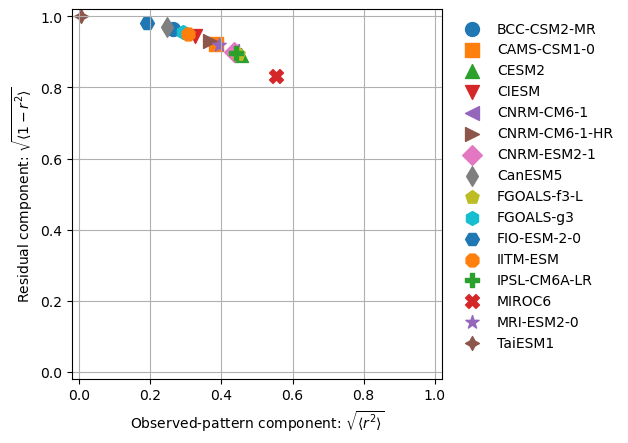

In [9]:
corr_TiR_dict = overlap_mean_member_decomposition['historical_matched']['corr_Ti_R']

for i,model in enumerate(overlap_model_names['historical_matched']):
    # Replace the calculations inside your existing model loop with these.
    # These are square roots of MEAN MEMBER VARIANCE FRACTIONS,
    # not ratios of mean component SDs.
    d = corr_TiR_dict[model]
    pattern_fraction = d["pattern_variance_fraction"]     # Mean of r_member**2.
    residual_fraction = d["residual_variance_fraction"]   # Mean of 1 - r_member**2.

    plt.scatter(np.sqrt(pattern_fraction), np.sqrt(residual_fraction),
                label=model, marker=TAYLOR_SHAPES[i], s=100)
    print(model, pattern_fraction + residual_fraction)    # Approximately 1.
plt.axis('square')
plt.xlim(-0.02,1.02)
plt.ylim(-0.02,1.02)
plt.grid(True)
plt.xlabel(r"Observed-pattern component: $\sqrt{\langle r^2\rangle}$")
plt.ylabel(r"Residual component: $\sqrt{\langle 1-r^2\rangle}$")
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1.), frameon=False,)

In [10]:
ECS     = np.array([3.02, 2.29, 5.15, 5.63, 4.90, 4.33, 4.79, 5.64, 2.98, 2.87, np.nan, 2.37, 4.70, 2.60, 3.13, 4.36])

BCC-CSM2-MR 1.0
CAMS-CSM1-0 1.0
CESM2 1.0
CIESM 1.0
CNRM-CM6-1 1.0
CNRM-CM6-1-HR 1.0
CNRM-ESM2-1 1.0
CanESM5 1.0
FGOALS-f3-L 1.0
FGOALS-g3 1.0
FIO-ESM-2-0 1.0
IITM-ESM 1.0
IPSL-CM6A-LR 1.0
MIROC6 1.0
MRI-ESM2-0 1.0
TaiESM1 1.0


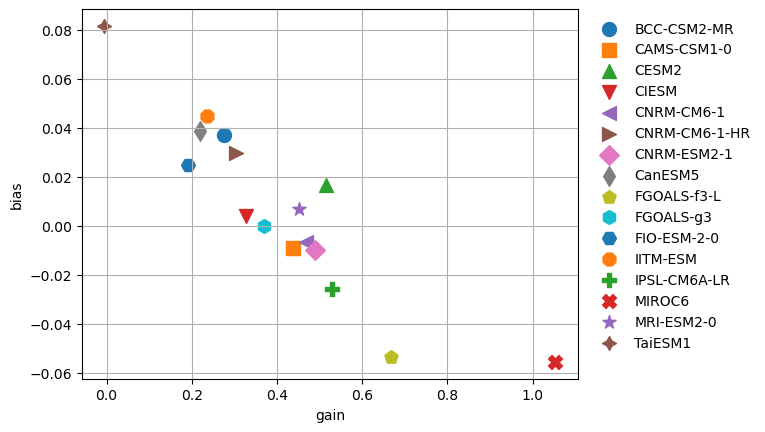

In [11]:
for i,model in enumerate(overlap_model_names['historical_matched']):
    # Replace the calculations inside your existing model loop with these.
    # These are square roots of MEAN MEMBER VARIANCE FRACTIONS,
    # not ratios of mean component SDs.
    d = corr_TiR_dict[model]
    gain = d["gain"]     # Mean of r_member**2.
    bias = overlap_mean_member_scores['historical_matched']['corr_Ti_R'][model]["bias"]   # Mean of 1 - r_member**2.

    plt.scatter(gain, bias,
                label=model, marker=TAYLOR_SHAPES[i], s=100)
    print(model, pattern_fraction + residual_fraction)    # Approximately 1.
# plt.axis('square')
# plt.xlim(-0.02,1.02)
# plt.ylim(-0.02,1.02)
plt.grid(True)
plt.xlabel('gain')
plt.ylabel('bias')
# plt.xlabel(r"Observed-pattern component: $\sqrt{\langle r^2\rangle}$")
# plt.ylabel(r"Residual component: $\sqrt{\langle 1-r^2\rangle}$")
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1.), frameon=False,)



BCC-CSM2-MR 1.0
CAMS-CSM1-0 1.0
CESM2 1.0
CIESM 1.0
CNRM-CM6-1 1.0
CNRM-CM6-1-HR 1.0
CNRM-ESM2-1 1.0
CanESM5 1.0
FGOALS-f3-L 1.0
FGOALS-g3 1.0
FIO-ESM-2-0 1.0
IITM-ESM 1.0
IPSL-CM6A-LR 1.0
MIROC6 1.0
MRI-ESM2-0 1.0
TaiESM1 1.0


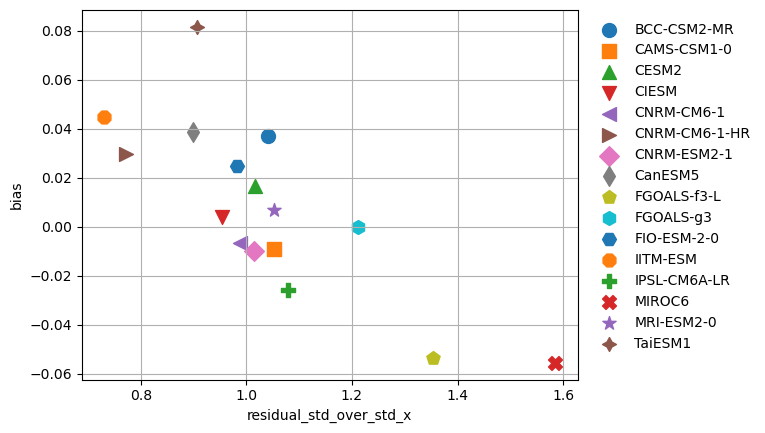

In [15]:
for i,model in enumerate(overlap_model_names['historical_matched']):
    # Replace the calculations inside your existing model loop with these.
    # These are square roots of MEAN MEMBER VARIANCE FRACTIONS,
    # not ratios of mean component SDs.
    d = corr_TiR_dict[model]
    H = d["residual_std_over_std_x"]     # Mean of r_member**2.
    bias = overlap_mean_member_scores['historical_matched']['corr_Ti_R'][model]["bias"]   # Mean of 1 - r_member**2.

    plt.scatter(H, bias,
                label=model, marker=TAYLOR_SHAPES[i], s=100)
    print(model, pattern_fraction + residual_fraction)    # Approximately 1.
# plt.axis('square')
# plt.xlim(-0.02,1.02)
# plt.ylim(-0.02,1.02)
plt.grid(True)
plt.xlabel('residual_std_over_std_x')
plt.ylabel('bias')
# plt.xlabel(r"Observed-pattern component: $\sqrt{\langle r^2\rangle}$")
# plt.ylabel(r"Residual component: $\sqrt{\langle 1-r^2\rangle}$")
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1.), frameon=False,)



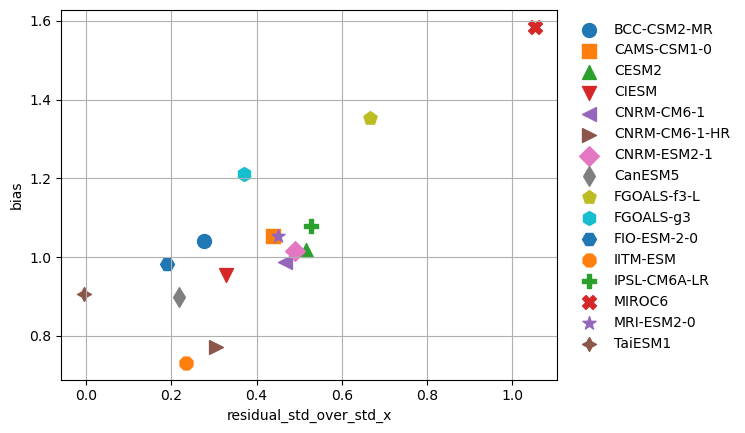

In [16]:
for i,model in enumerate(overlap_model_names['historical_matched']):
    # Replace the calculations inside your existing model loop with these.
    # These are square roots of MEAN MEMBER VARIANCE FRACTIONS,
    # not ratios of mean component SDs.
    d = corr_TiR_dict[model]
    gain = d["gain"]     # Mean of r_member**2.
    H = d["residual_std_over_std_x"]     # Mean of r_member**2.
    bias = overlap_mean_member_scores['historical_matched']['corr_Ti_R'][model]["bias"]   # Mean of 1 - r_member**2.

    plt.scatter(gain, H,
                label=model, marker=TAYLOR_SHAPES[i], s=100)
    # print(model, pattern_fraction + residual_fraction)    # Approximately 1.
# plt.axis('square')
# plt.xlim(-0.02,1.02)
# plt.ylim(-0.02,1.02)
plt.grid(True)
plt.xlabel('residual_std_over_std_x')
plt.ylabel('bias')
# plt.xlabel(r"Observed-pattern component: $\sqrt{\langle r^2\rangle}$")
# plt.ylabel(r"Residual component: $\sqrt{\langle 1-r^2\rangle}$")
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1.), frameon=False,)

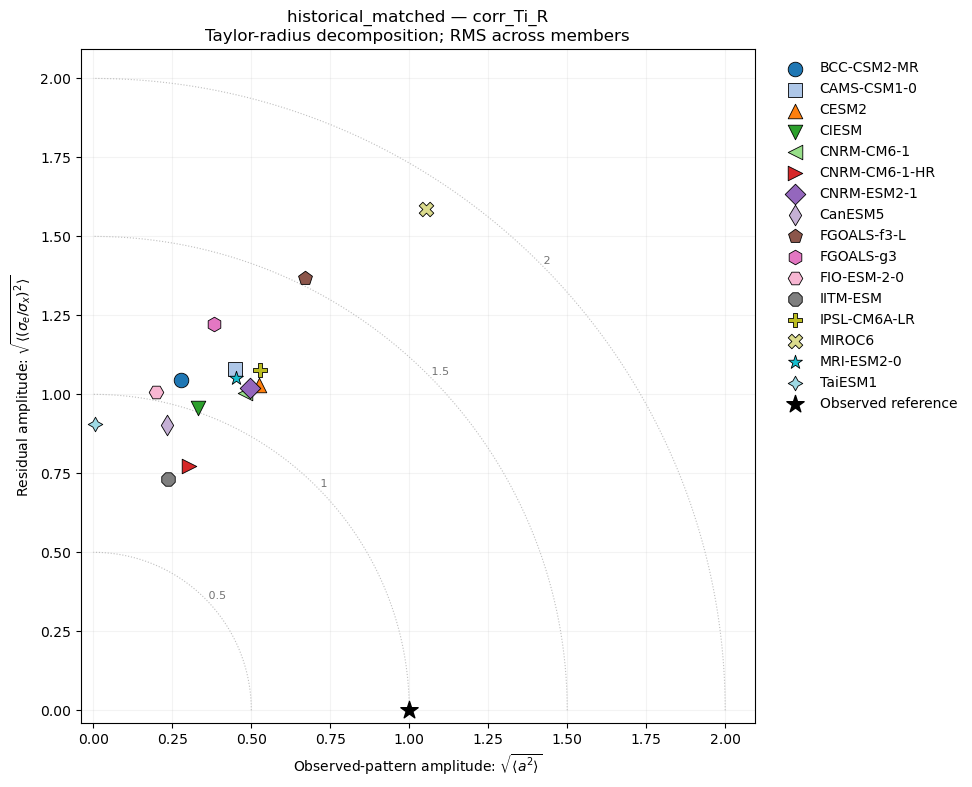

In [13]:
import numpy as np
import matplotlib.pyplot as plt

experiment, quantity = "historical_matched", "corr_Ti_R"
models = list(overlap_model_names[experiment])
decomposition = overlap_member_decomposition[experiment][quantity]
show_members = False                  # True adds faint individual-member points.

fig, ax = plt.subplots(figsize=(9, 8))
colors = plt.cm.tab20(np.linspace(0, 1, len(models)))
largest_radius = 1.0

# Calculate component amplitudes PER MEMBER before averaging their squares.
# Both axes are normalized by the observed diagnostic map's spatial SD.
for i, model in enumerate(models):
    d = decomposition[model]
    gain, residual, radius = [np.asarray(d[k], dtype=float) for k in
                             ["gain", "residual_std_over_std_x", "contrast_ratio"]]
    valid = np.isfinite(gain) & np.isfinite(residual) & np.isfinite(radius)
    if not valid.any():
        print(f"Skipping {model}: no defined member fits.")
        continue

    gain, residual, radius = gain[valid], residual[valid], radius[valid]
    np.testing.assert_allclose(gain**2 + residual**2, radius**2, rtol=1e-8, atol=1e-12)
    gain_rms = np.sqrt(np.mean(gain**2))
    residual_rms = np.sqrt(np.mean(residual**2))
    radius_rms = np.sqrt(np.mean(radius**2))
    marker = TAYLOR_SHAPES[i % len(TAYLOR_SHAPES)]

    # Positive amplitudes: a negative gain contributes the same variance as
    # an equally large positive gain. Inspect signed gain separately.
    if show_members:
        ax.scatter(np.abs(gain), residual, color=colors[i], marker=marker,
                   s=30, alpha=.2, linewidths=0, zorder=2)
    ax.scatter(gain_rms, residual_rms, color=colors[i], marker=marker,
               s=110, edgecolors="k", linewidths=.6, label=model, zorder=3)
    largest_radius = max(largest_radius, radius.max() if show_members else radius_rms)

# Circles mark constant Taylor-radius amplitude; unlike the earlier fraction
# plot, points are NOT forced onto a unit circle. Their distance is informative.
limit = 1.1 * largest_radius
theta = np.linspace(0, np.pi / 2, 200)
for value in np.arange(.5, limit, .5):
    ax.plot(value*np.cos(theta), value*np.sin(theta), color=".75", ls=":", lw=.8, zorder=0)
    ax.text(value/np.sqrt(2), value/np.sqrt(2), f" {value:g}", fontsize=8, color=".45")

ax.scatter(1, 0, marker="*", s=170, color="black", label="Observed reference", zorder=4)
ax.set(xlim=(-.04, limit), ylim=(-.04, limit),
       xlabel=r"Observed-pattern amplitude: $\sqrt{\langle a^2\rangle}$",
       ylabel=r"Residual amplitude: $\sqrt{\langle(\sigma_e/\sigma_x)^2\rangle}$",
       title=f"{experiment} — {quantity}\nTaylor-radius decomposition; RMS across members")
ax.set_aspect("equal", adjustable="box")
ax.grid(True, alpha=.15)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False)
plt.tight_layout()
plt.show()

In [14]:
# %% Encode the CMIP6 forced-response table and match it to our overlap models.
import numpy as np
import pandas as pd
from io import StringIO

# This is the complete model-by-model table, version 2.2 (2022-06-15), checked
# against the source on 2026-09-16. Embedding it makes this cell work offline.
# We omit the source's Average and 1-sigma rows: those summarize its model set,
# not necessarily ours. All values retain the source's two-decimal precision.
cmip6_forced_text = """MODEL VARIANT ECS ERF2x PL PL* LR LR* WV RH ALB CLD SWCLD LWCLD NET ERR
ACCESS-CM2 r1i1p1f1 4.66 3.43 -3.29 -1.91 -0.47 -0.05 1.72 -0.07 0.39 0.76 0.96 -0.20 -0.74 0.15
ACCESS-ESM1-5 r1i1p1f1 3.88 2.83 -3.27 -1.91 -0.30 0.02 1.70 0.02 0.46 0.56 0.43 0.13 -0.73 0.12
AWI-CM-1-1-MR r1i1p1f1 3.16 3.63 -3.23 -1.88 -0.41 -0.03 1.77 0.03 0.46 0.22 -0.31 0.53 -1.15 0.04
BCC-CSM2-MR r1i1p1f1 3.02 3.11 -3.31 -1.95 -0.36 0.01 1.67 -0.07 0.43 0.51 0.16 0.35 -1.03 0.04
BCC-ESM1 r1i1p1f1 3.25 3.01 -3.29 -1.94 -0.35 0.01 1.66 -0.05 0.47 0.52 0.02 0.50 -0.92 0.07
CAMS-CSM1-0 r1i1p1f1 2.29 4.17 -3.31 -1.91 -0.62 -0.05 2.01 0.05 0.26 -0.36 -0.72 0.36 -1.82 0.19
CESM2 r1i1p1f1 5.15 3.27 -3.34 -1.93 -0.53 -0.08 1.87 0.00 0.40 0.96 0.79 0.17 -0.63 0.01
CESM2-FV2 r1i1p1f1 5.16 2.86 -3.30 -1.92 -0.51 -0.07 1.74 -0.07 0.43 1.06 0.95 0.11 -0.55 0.03
CESM2-WACCM r1i1p1f1 4.68 3.30 -3.34 -1.94 -0.54 -0.07 1.86 -0.01 0.40 1.17 1.05 0.12 -0.71 -0.25
CESM2-WACCM-FV2 r1i1p1f1 4.80 2.92 -3.31 -1.93 -0.52 -0.07 1.75 -0.09 0.41 1.13 0.97 0.15 -0.61 -0.06
CIESM r1i1p1f1 5.63 3.86 -3.25 -1.89 -0.35 -0.01 1.60 -0.10 0.29 0.81 0.68 0.13 -0.69 0.21
CMCC-CM2-SR5 r1i1p1f1 3.55 3.79 -3.32 -1.92 -0.47 -0.04 1.82 -0.01 0.34 0.52 0.48 0.04 -1.07 0.04
CMCC-ESM2 r1i1p1f1 3.58 3.75 -3.31 -1.92 -0.47 -0.04 1.84 0.02 0.37 0.50 0.45 0.05 -1.05 0.03
CNRM-CM6-1 r1i1p1f2 4.90 3.64 -3.29 -1.92 -0.42 -0.01 1.75 -0.02 0.53 0.55 -0.02 0.57 -0.74 0.13
CNRM-CM6-1-HR r1i1p1f2 4.33 3.96 -3.33 -1.93 -0.56 -0.07 1.92 0.02 0.40 0.54 -0.10 0.64 -0.92 0.12
CNRM-ESM2-1 r1i1p1f2 4.79 2.97 -3.29 -1.91 -0.47 -0.04 1.83 0.01 0.51 0.56 0.03 0.53 -0.62 0.24
CanESM5 r1i1p1f1 5.64 3.68 -3.33 -1.94 -0.61 -0.10 1.97 0.07 0.47 0.80 -0.02 0.82 -0.65 0.03
E3SM-1-0 r1i1p1f1 5.31 3.33 -3.33 -1.92 -0.54 -0.10 1.86 0.01 0.34 0.94 0.75 0.18 -0.63 0.11
EC-Earth3 r8i1p1f1 4.26 3.22 -3.24 -1.88 -0.16 0.06 1.68 0.11 0.60 0.31 0.05 0.26 -0.76 0.05
EC-Earth3-AerChem r1i1p1f1 3.87 3.63 -3.24 -1.87 -0.27 0.01 1.74 0.08 0.59 0.20 -0.09 0.28 -0.94 0.06
EC-Earth3-CC r1i1p1f1 4.23 3.25 -3.23 -1.87 -0.25 0.03 1.72 0.09 0.63 0.29 0.06 0.23 -0.77 0.07
EC-Earth3-Veg r1i1p1f1 4.33 3.37 -3.26 -1.89 -0.20 0.04 1.73 0.11 0.60 0.29 0.02 0.27 -0.78 0.07
EC-Earth3-Veg-LR r1i1p1f1 4.23 3.25 -3.26 -1.88 -0.29 0.01 1.72 0.05 0.56 0.41 0.12 0.28 -0.77 0.09
FGOALS-f3-L r1i1p1f1 2.98 4.17 -3.20 -1.88 -0.37 0.01 1.65 -0.05 0.40 -0.01 -0.21 0.20 -1.40 0.14
FGOALS-g3 r1i1p1f1 2.87 3.58 -3.29 -1.93 -0.37 0.03 1.90 0.14 0.57 -0.01 -0.73 0.72 -1.25 -0.06
GFDL-CM4 r1i1p1f1 3.89 3.19 -3.24 -1.89 -0.53 -0.07 1.84 0.03 0.55 0.56 0.03 0.53 -0.82 -0.00
GFDL-ESM4 r1i1p1f1 2.65 3.77 -3.31 -1.90 -0.68 -0.13 1.94 -0.01 0.37 0.44 -0.15 0.59 -1.42 -0.19
GISS-E2-1-G r1i1p1f1 2.71 3.95 -3.26 -1.87 -1.03 -0.21 2.19 -0.01 0.27 0.00 -0.63 0.64 -1.46 0.37
GISS-E2-1-H r1i1p1f1 3.12 3.53 -3.22 -1.89 -0.55 -0.03 1.91 0.07 0.48 -0.03 -0.53 0.50 -1.13 0.27
GISS-E2-2-G r1i1p1f1 2.43 3.65 -3.24 -1.85 -0.84 -0.15 2.11 0.03 0.39 -0.09 -0.88 0.79 -1.51 0.17
GISS-E2-2-H r1i1p1f1 2.68 3.42 -3.19 -1.87 -0.43 -0.02 1.73 0.00 0.46 -0.04 -0.62 0.58 -1.28 0.20
HadGEM3-GC31-LL r1i1p1f3 5.55 3.49 -3.27 -1.91 -0.41 -0.03 1.68 -0.07 0.41 0.79 0.98 -0.19 -0.63 0.18
HadGEM3-GC31-MM r1i1p1f3 5.44 3.57 -3.29 -1.91 -0.44 -0.05 1.69 -0.08 0.35 0.87 1.03 -0.17 -0.66 0.17
IITM-ESM r1i1p1f1 2.37 4.51 -3.28 -1.91 -0.74 -0.14 1.99 0.02 0.29 -0.08 -0.69 0.62 -1.91 -0.09
INM-CM4-8 r1i1p1f1 1.83 2.70 -3.29 -1.95 -0.09 0.10 1.61 0.08 0.40 -0.13 -0.19 0.06 -1.48 0.02
INM-CM5-0 r1i1p1f1 1.92 2.92 -3.29 -1.95 -0.11 0.09 1.58 0.03 0.45 -0.11 -0.11 -0.00 -1.52 -0.03
IPSL-CM5A2-INCA r1i1p1f1 3.82 3.07 -3.31 -1.90 -0.73 -0.11 2.06 0.04 0.36 0.98 0.50 0.48 -0.81 -0.17
IPSL-CM6A-LR r1i1p1f1 4.70 3.58 -3.28 -1.91 -0.50 -0.03 1.96 0.10 0.48 0.38 0.14 0.23 -0.76 0.21
IPSL-CM6A-LR-INCA r1i1p1f1 4.13 3.15 -3.28 -1.90 -0.52 -0.04 1.93 0.07 0.49 0.43 0.19 0.24 -0.76 0.19
KACE-1-0-G r1i1p1f1 4.75 3.41 -3.30 -1.91 -0.51 -0.08 1.76 -0.07 0.36 0.80 0.98 -0.19 -0.72 0.18
MIROC-ES2L r1i1p1f2 2.66 4.11 -3.31 -1.91 -0.70 -0.11 1.98 -0.01 0.44 -0.02 -0.35 0.33 -1.54 0.07
MIROC6 r1i1p1f1 2.60 3.65 -3.34 -1.89 -0.64 -0.10 2.03 0.05 0.51 0.12 -0.13 0.26 -1.40 -0.10
MPI-ESM-1-2-HAM r1i1p1f1 2.95 4.16 -3.16 -1.85 -0.66 -0.09 1.92 0.04 0.39 -0.23 -0.62 0.39 -1.41 0.33
MPI-ESM1-2-HR r1i1p1f1 2.98 3.65 -3.20 -1.86 -0.53 -0.06 1.83 0.03 0.42 0.20 -0.41 0.61 -1.22 0.06
MPI-ESM1-2-LR r1i1p1f1 3.03 4.22 -3.16 -1.84 -0.76 -0.13 1.97 0.02 0.39 0.12 -0.68 0.79 -1.39 0.05
MRI-ESM2-0 r1i1p1f1 3.13 3.43 -3.27 -1.92 -0.48 -0.03 1.71 -0.08 0.60 0.38 0.12 0.26 -1.10 -0.04
NESM3 r1i1p1f1 4.76 3.73 -3.15 -1.87 -0.55 -0.02 1.83 0.02 0.54 0.38 -0.15 0.53 -0.78 0.17
NorCPM1 r1i1p1f1 3.03 3.34 -3.23 -1.93 -0.18 0.09 1.56 -0.00 0.50 0.23 -0.01 0.24 -1.10 0.01
NorESM2-LM r1i1p1f1 2.56 3.43 -3.35 -1.90 -0.67 -0.13 2.03 0.03 0.40 0.36 0.21 0.15 -1.34 -0.10
NorESM2-MM r1i1p1f1 2.49 3.73 -3.36 -1.90 -0.75 -0.16 2.11 0.06 0.34 0.43 0.30 0.14 -1.50 -0.27
SAM0-UNICON r1i1p1f1 3.72 3.89 -3.33 -1.93 -0.58 -0.08 1.77 -0.13 0.42 0.69 0.89 -0.20 -1.04 -0.01
TaiESM1 r1i1p1f1 4.36 3.85 -3.31 -1.94 -0.43 -0.02 1.77 -0.02 0.43 0.64 0.55 0.09 -0.88 0.02
UKESM1-0-LL r1i1p1f2 5.36 3.61 -3.26 -1.90 -0.35 -0.00 1.60 -0.10 0.53 0.81 0.93 -0.12 -0.67 -0.00
"""

# Keep the original column names, including PL* and LR*. The dictionary below
# gives their meanings; the DataFrame is convenient for inspecting all columns.
cmip6_forced_table = pd.read_csv(StringIO(cmip6_forced_text), sep=r"\s+").set_index("MODEL")
forced_property_names = [name for name in cmip6_forced_table.columns if name != "VARIANT"]
if not cmip6_forced_table.index.is_unique or len(cmip6_forced_table) != 53:
    raise ValueError("Expected the 53 unique models in this encoded source snapshot.")
cmip6_forced_table[forced_property_names] = cmip6_forced_table[forced_property_names].astype(float)
if not np.isfinite(cmip6_forced_table[forced_property_names].to_numpy()).all():
    raise ValueError("An encoded numeric value is missing or nonfinite.")
cmip6_forced_properties = cmip6_forced_table.to_dict(orient="index")

# Units and provenance travel separately from the numeric dictionaries.
# ECS is EFFECTIVE climate sensitivity, not a direct equilibrated warming.
# Negative NET is stabilizing in the source convention: ECS = -ERF2x / NET.
# ERR is a kernel closure residual, NOT a standard error or uncertainty.
forced_property_info = {
    "ECS":   {"units": "K", "meaning": "Effective climate sensitivity"},
    "ERF2x": {"units": "W m-2", "meaning": "Effective forcing for doubled CO2"},
}
feedback_meanings = {
    "PL": "Planck", "PL*": "Constant-RH Planck",
    "LR": "Lapse rate", "LR*": "Constant-RH lapse rate",
    "WV": "Water vapor", "RH": "Relative humidity", "ALB": "Surface albedo",
    "CLD": "Net cloud", "SWCLD": "Shortwave cloud", "LWCLD": "Longwave cloud",
    "NET": "Net", "ERR": "Kernel residual",
}
for property_name, meaning in feedback_meanings.items():
    forced_property_info[property_name] = {"units": "W m-2 K-1", "meaning": meaning + " feedback"}

# Match EXACT model names to the existing groups without changing their order.
# Missing source models stay present with NaN properties, rather than silently
# shortening arrays or substituting a related model. No member axis is created:
# each value describes the source's listed abrupt-4xCO2 variant of that model.
overlap_forced_properties, overlap_forced_missing, forced_model_names = {}, {}, {}
for experiment in ["historical", "historical_matched", "amip_hist"]:
    names = list(overlap_model_names[experiment])
    if len(names) != len(set(names)):
        raise ValueError(f"{experiment}: duplicate model names.")
    forced_model_names[experiment] = names.copy()
    selected = cmip6_forced_table.reindex(names)
    overlap_forced_properties[experiment] = selected[forced_property_names].to_dict()
    missing = [model for model in names if model not in cmip6_forced_table.index]
    overlap_forced_missing[experiment] = missing
    print(f"{experiment}: {len(names) - len(missing)}/{len(names)} models matched; missing: {missing}")

# Historical and AMIP copies carry the SAME external property for the same
# model. These are not separate AMIP sensitivity measurements, member means,
# or extra independent observations when combining the experiment groups.
overlap_forced_metadata = {
    "source_url": "https://github.com/mzelinka/cmip56_forcing_feedback_ecs/blob/master/CMIP6_ECS_ERF_fbks.txt",
    "documentation_url": "https://github.com/mzelinka/cmip56_forcing_feedback_ecs#table-contents",
    "source_version": "2.2", "source_modified": "2022-06-15", "checked_on": "2026-09-16",
    "source_experiment": "abrupt-4xCO2", "numeric_precision": "Source table rounded to 2 decimal places",
    "property_info": forced_property_info, "model_names": forced_model_names,
    "source_variants": cmip6_forced_table["VARIANT"].to_dict(), "missing_models": overlap_forced_missing,
    "indexing": "overlap_forced_properties[experiment][property][model] -> scalar",
}

# The two equivalent temperature/humidity partitions are alternatives:
# PL + LR + WV ~= PL* + LR* + RH; likewise CLD ~= SWCLD + LWCLD.
# Do not sum every feedback column together. Approximate equality reflects
# rounding; retain the tabulated ECS instead of recomputing it from rounded NET.


historical: 44/53 models matched; missing: ['AWI-ESM-1-1-LR', 'CAS-ESM2-0', 'CMCC-CM2-HR4', 'CanESM5-CanOE', 'E3SM-1-1', 'E3SM-1-1-ECA', 'FIO-ESM-2-0', 'GISS-E2-1-G-CC', 'KIOST-ESM']
historical_matched: 15/16 models matched; missing: ['FIO-ESM-2-0']
amip_hist: 15/16 models matched; missing: ['FIO-ESM-2-0']


In [21]:
overlap_forced_properties

{'historical': {'ECS': {'ACCESS-CM2': 4.66,
   'ACCESS-ESM1-5': 3.88,
   'AWI-CM-1-1-MR': 3.16,
   'AWI-ESM-1-1-LR': nan,
   'BCC-CSM2-MR': 3.02,
   'BCC-ESM1': 3.25,
   'CAMS-CSM1-0': 2.29,
   'CAS-ESM2-0': nan,
   'CESM2': 5.15,
   'CESM2-FV2': 5.16,
   'CESM2-WACCM': 4.68,
   'CESM2-WACCM-FV2': 4.8,
   'CIESM': 5.63,
   'CMCC-CM2-HR4': nan,
   'CMCC-CM2-SR5': 3.55,
   'CMCC-ESM2': 3.58,
   'CNRM-CM6-1': 4.9,
   'CNRM-CM6-1-HR': 4.33,
   'CNRM-ESM2-1': 4.79,
   'CanESM5': 5.64,
   'CanESM5-CanOE': nan,
   'E3SM-1-0': 5.31,
   'E3SM-1-1': nan,
   'E3SM-1-1-ECA': nan,
   'EC-Earth3': 4.26,
   'EC-Earth3-AerChem': 3.87,
   'EC-Earth3-Veg': 4.33,
   'EC-Earth3-Veg-LR': 4.23,
   'FGOALS-f3-L': 2.98,
   'FGOALS-g3': 2.87,
   'FIO-ESM-2-0': nan,
   'GISS-E2-1-G': 2.71,
   'GISS-E2-1-G-CC': nan,
   'GISS-E2-1-H': 3.12,
   'IITM-ESM': 2.37,
   'INM-CM4-8': 1.83,
   'INM-CM5-0': 1.92,
   'IPSL-CM5A2-INCA': 3.82,
   'IPSL-CM6A-LR': 4.7,
   'IPSL-CM6A-LR-INCA': 4.13,
   'KACE-1-0-G': 4.75,
   'K

In [24]:
corr_TiR_dict

{'BCC-CSM2-MR': {'gain': 0.2761814713662179,
  'offset': -0.002666616675094696,
  'pattern_std': 0.035348675803884115,
  'residual_std': 0.13324476175823716,
  'pattern_std_over_std_x': 0.2761814713662179,
  'residual_std_over_std_y': 0.9647922664888515,
  'pattern_variance_fraction': 0.06904737436619822,
  'residual_variance_fraction': 0.9309526256338018,
  'bias_from_gain': 0.03987854916025529,
  'bias': 0.03721193248516059,
  'pattern_correlation': 0.2591759581974838,
  'contrast_ratio': 1.0781537307943418,
  'offset_over_std_x': -0.020834447122809092,
  'residual_std_over_std_x': 1.0410498701110478,
  'bias_from_gain_over_std_x': 0.31157366245156964,
  'bias_over_std_x': 0.2907392153287605},
 'CAMS-CSM1-0': {'gain': 0.4384787019496567,
  'offset': -0.04007991596834536,
  'pattern_std': 0.05612122133122301,
  'residual_std': 0.13471423861595105,
  'pattern_std_over_std_x': 0.4384787019496567,
  'residual_std_over_std_y': 0.9227009076733529,
  'pattern_variance_fraction': 0.148474141

In [26]:
overlap_forced_properties['historical']

{'ECS': {'ACCESS-CM2': 4.66,
  'ACCESS-ESM1-5': 3.88,
  'AWI-CM-1-1-MR': 3.16,
  'AWI-ESM-1-1-LR': nan,
  'BCC-CSM2-MR': 3.02,
  'BCC-ESM1': 3.25,
  'CAMS-CSM1-0': 2.29,
  'CAS-ESM2-0': nan,
  'CESM2': 5.15,
  'CESM2-FV2': 5.16,
  'CESM2-WACCM': 4.68,
  'CESM2-WACCM-FV2': 4.8,
  'CIESM': 5.63,
  'CMCC-CM2-HR4': nan,
  'CMCC-CM2-SR5': 3.55,
  'CMCC-ESM2': 3.58,
  'CNRM-CM6-1': 4.9,
  'CNRM-CM6-1-HR': 4.33,
  'CNRM-ESM2-1': 4.79,
  'CanESM5': 5.64,
  'CanESM5-CanOE': nan,
  'E3SM-1-0': 5.31,
  'E3SM-1-1': nan,
  'E3SM-1-1-ECA': nan,
  'EC-Earth3': 4.26,
  'EC-Earth3-AerChem': 3.87,
  'EC-Earth3-Veg': 4.33,
  'EC-Earth3-Veg-LR': 4.23,
  'FGOALS-f3-L': 2.98,
  'FGOALS-g3': 2.87,
  'FIO-ESM-2-0': nan,
  'GISS-E2-1-G': 2.71,
  'GISS-E2-1-G-CC': nan,
  'GISS-E2-1-H': 3.12,
  'IITM-ESM': 2.37,
  'INM-CM4-8': 1.83,
  'INM-CM5-0': 1.92,
  'IPSL-CM5A2-INCA': 3.82,
  'IPSL-CM6A-LR': 4.7,
  'IPSL-CM6A-LR-INCA': 4.13,
  'KACE-1-0-G': 4.75,
  'KIOST-ESM': nan,
  'MIROC6': 2.6,
  'MPI-ESM-1-2-HAM': 2.

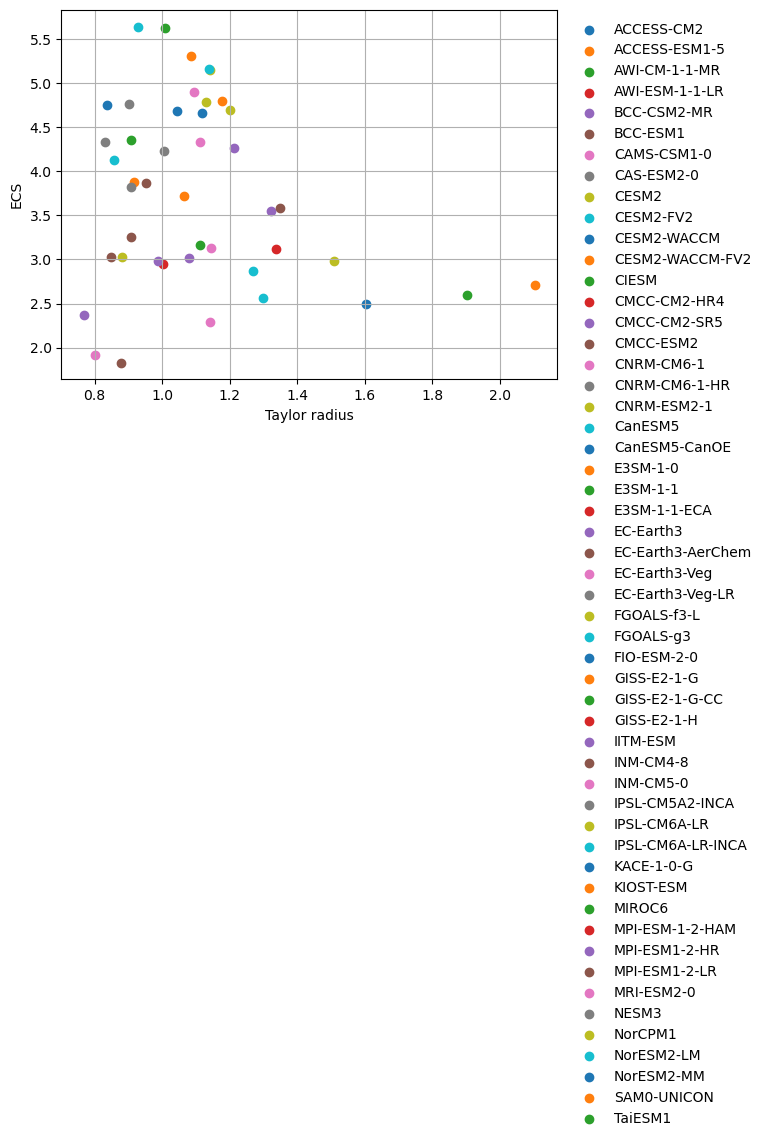

In [29]:
corr_TiR_dict = overlap_mean_member_decomposition['historical']['corr_Ti_R']
for i,model in enumerate(overlap_model_names['historical']):
    # Replace the calculations inside your existing model loop with these.
    # These are square roots of MEAN MEMBER VARIANCE FRACTIONS,
    # not ratios of mean component SDs.
    d = corr_TiR_dict[model]
    gain = d["gain"]     # Mean of r_member**2.
    H = d["residual_std_over_std_x"]     # Mean of r_member**2.
    bias = overlap_mean_member_scores['historical']['corr_Ti_R'][model]["bias"]   # Mean of 1 - r_member**2.
    radius_Taylor = d["contrast_ratio"] 
    ECS = overlap_forced_properties['historical']['ECS'][model]

    plt.scatter(radius_Taylor, ECS,
                label=model,)# marker=TAYLOR_SHAPES[i], s=100)
    # print(model, pattern_fraction + residual_fraction)    # Approximately 1.
# plt.axis('square')
# plt.xlim(-0.02,1.02)
# plt.ylim(-0.02,1.02)
plt.grid(True)
plt.xlabel('Taylor radius')
plt.ylabel('ECS')
# plt.xlabel(r"Observed-pattern component: $\sqrt{\langle r^2\rangle}$")
# plt.ylabel(r"Residual component: $\sqrt{\langle 1-r^2\rangle}$")
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1.), frameon=False,)

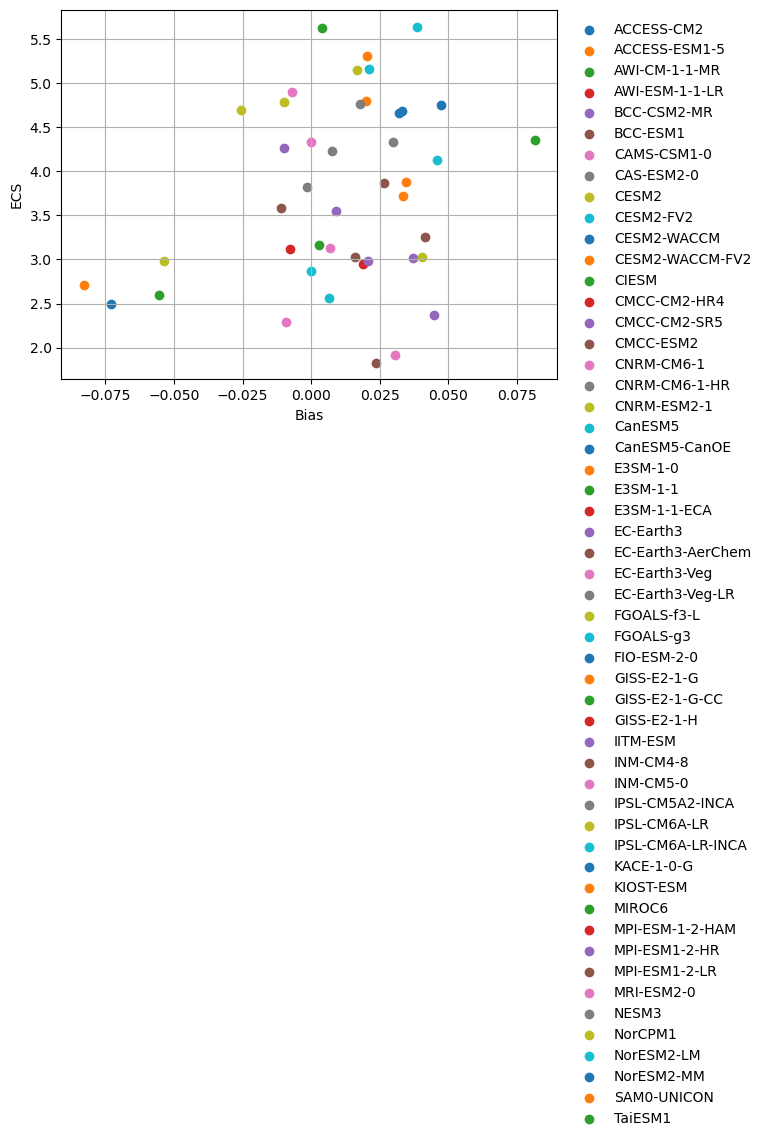

In [33]:
corr_TiR_dict = overlap_mean_member_decomposition['historical']['corr_Ti_R']
for i,model in enumerate(overlap_model_names['historical']):
    # Replace the calculations inside your existing model loop with these.
    # These are square roots of MEAN MEMBER VARIANCE FRACTIONS,
    # not ratios of mean component SDs.
    d = corr_TiR_dict[model]
    gain = d["gain"]     # Mean of r_member**2.
    H = d["residual_std_over_std_x"]     # Mean of r_member**2.
    bias = overlap_mean_member_scores['historical']['corr_Ti_R'][model]["bias"]   # Mean of 1 - r_member**2.
    radius_Taylor = d["contrast_ratio"] 
    ECS = overlap_forced_properties['historical']['ECS'][model]

    plt.scatter(bias, ECS,
                label=model,)# marker=TAYLOR_SHAPES[i], s=100)
    # print(model, pattern_fraction + residual_fraction)    # Approximately 1.
# plt.axis('square')
# plt.xlim(-0.02,1.02)
# plt.ylim(-0.02,1.02)
plt.grid(True)
plt.xlabel('Bias')
plt.ylabel('ECS')
# plt.xlabel(r"Observed-pattern component: $\sqrt{\langle r^2\rangle}$")
# plt.ylabel(r"Residual component: $\sqrt{\langle 1-r^2\rangle}$")
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1.), frameon=False,)

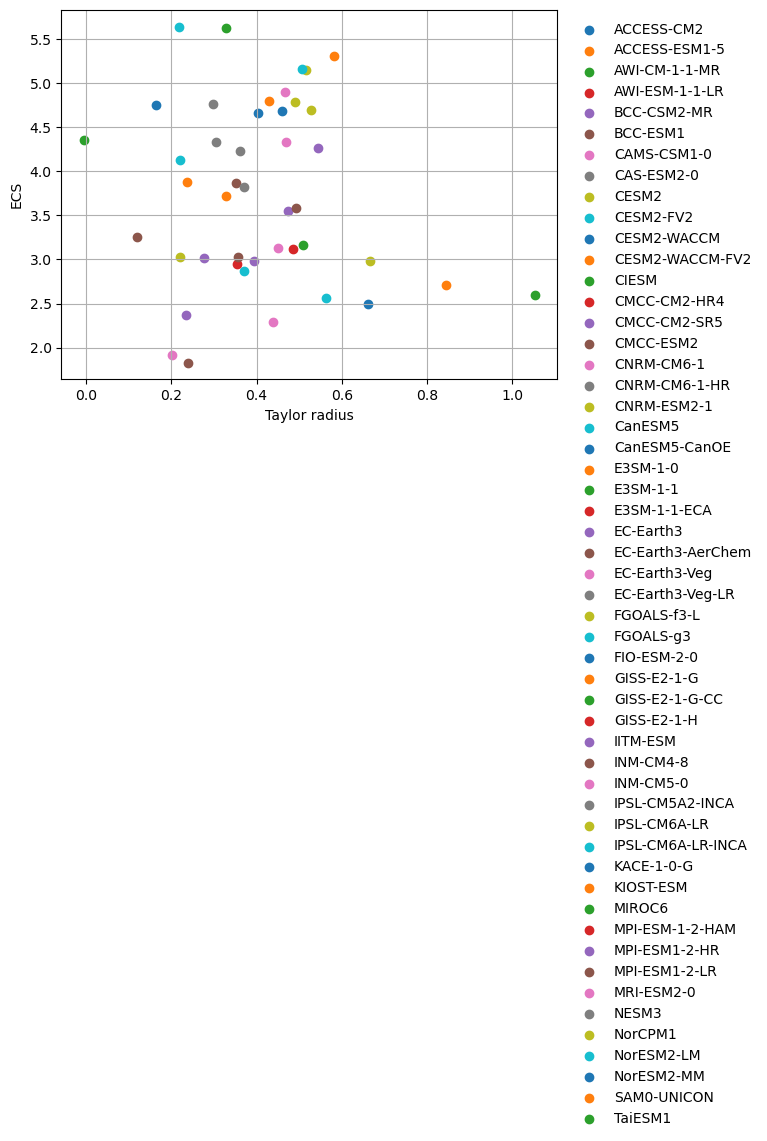

In [31]:
corr_TiR_dict = overlap_mean_member_decomposition['historical']['corr_Ti_R']
for i,model in enumerate(overlap_model_names['historical']):
    # Replace the calculations inside your existing model loop with these.
    # These are square roots of MEAN MEMBER VARIANCE FRACTIONS,
    # not ratios of mean component SDs.
    d = corr_TiR_dict[model]
    gain = d["gain"]     # Mean of r_member**2.
    H = d["residual_std_over_std_x"]     # Mean of r_member**2.
    bias = overlap_mean_member_scores['historical']['corr_Ti_R'][model]["bias"]   # Mean of 1 - r_member**2.
    radius_Taylor = d["contrast_ratio"] 
    ECS = overlap_forced_properties['historical']['ECS'][model]

    plt.scatter(gain, ECS,
                label=model,)# marker=TAYLOR_SHAPES[i], s=100)
    # print(model, pattern_fraction + residual_fraction)    # Approximately 1.
# plt.axis('square')
# plt.xlim(-0.02,1.02)
# plt.ylim(-0.02,1.02)
plt.grid(True)
plt.xlabel('Taylor radius')
plt.ylabel('ECS')
# plt.xlabel(r"Observed-pattern component: $\sqrt{\langle r^2\rangle}$")
# plt.ylabel(r"Residual component: $\sqrt{\langle 1-r^2\rangle}$")
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1.), frameon=False,)

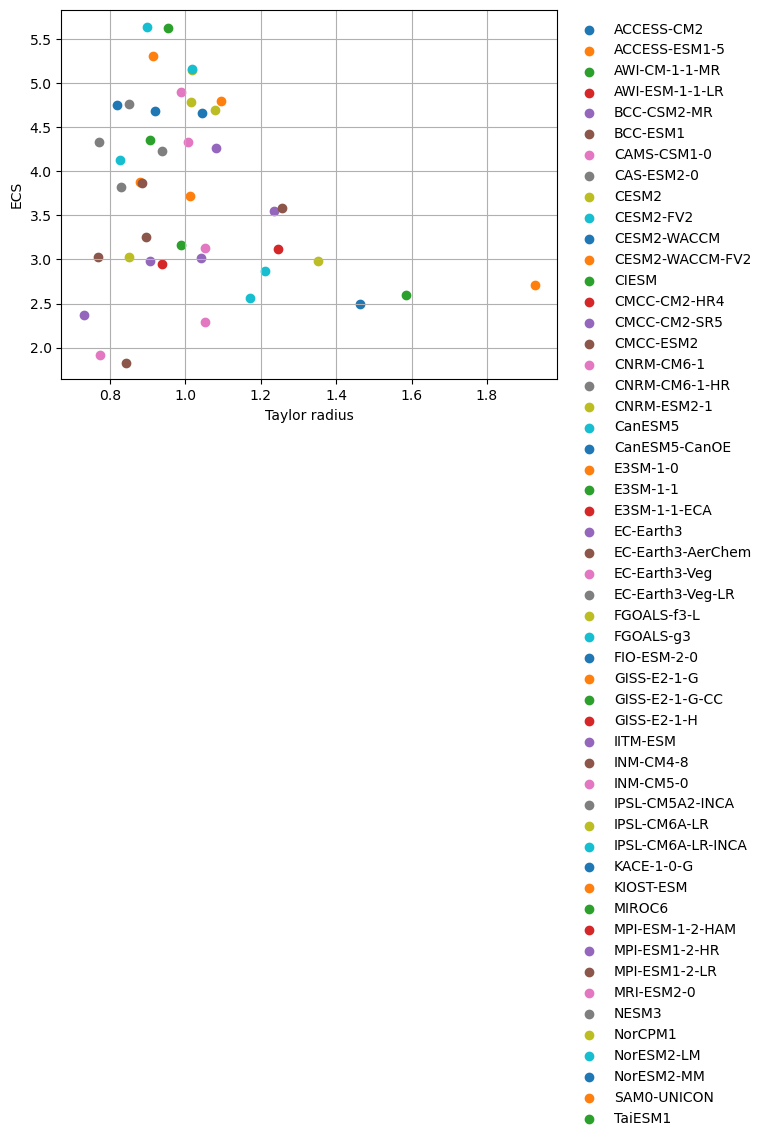

In [32]:
corr_TiR_dict = overlap_mean_member_decomposition['historical']['corr_Ti_R']
for i,model in enumerate(overlap_model_names['historical']):
    # Replace the calculations inside your existing model loop with these.
    # These are square roots of MEAN MEMBER VARIANCE FRACTIONS,
    # not ratios of mean component SDs.
    d = corr_TiR_dict[model]
    gain = d["gain"]     # Mean of r_member**2.
    H = d["residual_std_over_std_x"]     # Mean of r_member**2.
    bias = overlap_mean_member_scores['historical']['corr_Ti_R'][model]["bias"]   # Mean of 1 - r_member**2.
    radius_Taylor = d["contrast_ratio"] 
    ECS = overlap_forced_properties['historical']['ECS'][model]

    plt.scatter(H, ECS,
                label=model,)# marker=TAYLOR_SHAPES[i], s=100)
    # print(model, pattern_fraction + residual_fraction)    # Approximately 1.
# plt.axis('square')
# plt.xlim(-0.02,1.02)
# plt.ylim(-0.02,1.02)
plt.grid(True)
plt.xlabel('Taylor radius')
plt.ylabel('ECS')
# plt.xlabel(r"Observed-pattern component: $\sqrt{\langle r^2\rangle}$")
# plt.ylabel(r"Residual component: $\sqrt{\langle 1-r^2\rangle}$")
plt.legend(loc="upper left", bbox_to_anchor=(1.01, 1.), frameon=False,)

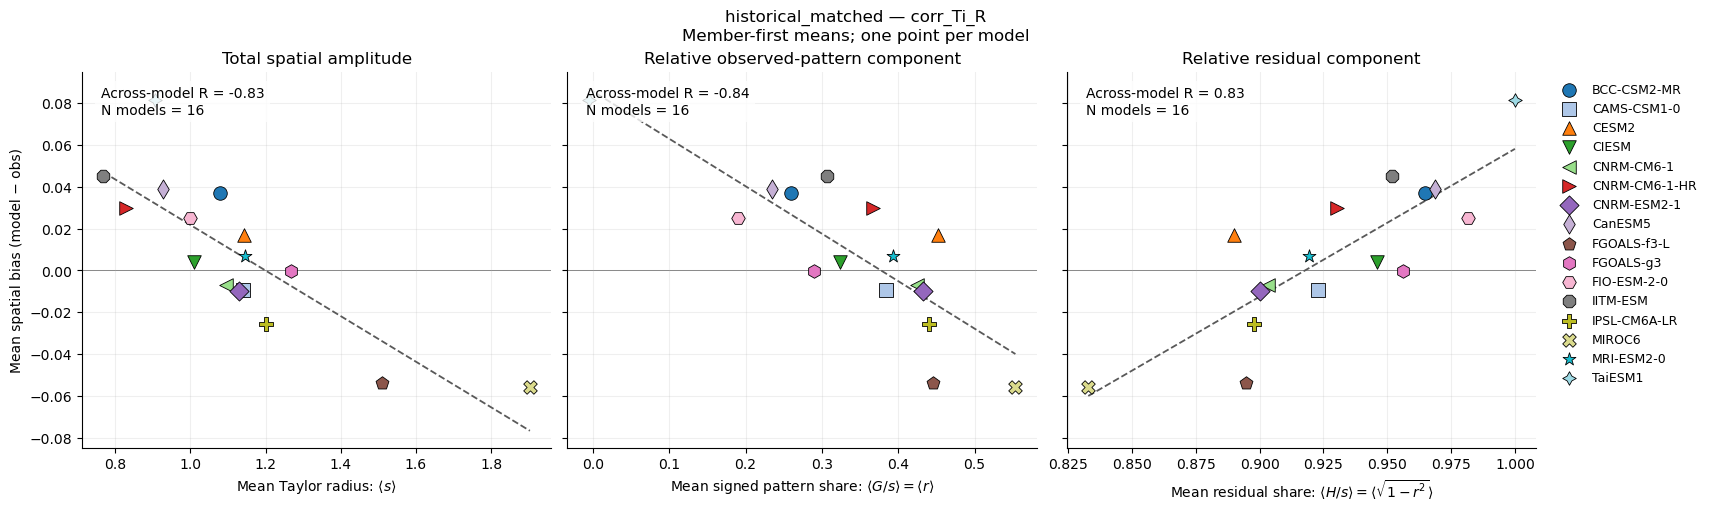

In [34]:
# %% Bias versus total amplitude and the two relative pattern components.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

experiment, quantity = "historical_matched", "corr_Ti_R"
bias_key = "bias"                       # Or "bias_over_std_x" for obs-SD-normalized bias.
show_members = False                   # True adds faint members; fits still use model means only.

# Read MEMBER decompositions, not the pre-averaged decomposition dictionary.
# s is Taylor radius, G is signed gain, and H is residual SD / obs spatial SD.
# Compute G/s and H/s for each member FIRST, then average within each model.
model_names = list(overlap_model_names[experiment])
component_members, mean_rows = {}, []

for model in model_names:
    d = overlap_member_decomposition[experiment][quantity][model]
    s, G, H, bias = [np.asarray(d[key], dtype=float) for key in
                     ["contrast_ratio", "gain", "residual_std_over_std_x", bias_key]]
    if s.ndim != 1 or any(v.shape != s.shape for v in [G, H, bias]):
        raise ValueError(f"{model}: expected matching one-dimensional member arrays.")

    # Use the SAME members for every panel and for that model's mean bias.
    # Constant maps (s=0) have undefined shares, so exclude them from all panels.
    valid = np.isfinite(s) & np.isfinite(G) & np.isfinite(H) & np.isfinite(bias) & (s > 0)
    s, G, H, bias = s[valid], G[valid], H[valid], bias[valid]
    here = {"s": s, "G_over_s": G / s, "H_over_s": H / s, "bias": bias}
    component_members[model] = here
    mean_rows.append({"model": model, "n_members": len(s),
                      **{key: values.mean() if values.size else np.nan for key, values in here.items()}})
    if not len(s):
        print(f"Excluded {model}: no members with defined amplitude, shares, and bias.")

# Keep these plotted values available to inspect or reuse afterward.
# Each row is one model's mean of member-level quantities, NOT a mean-map fit.
bias_component_means = pd.DataFrame(mean_rows).set_index("model")
bias_component_means.attrs.update(experiment=experiment, quantity=quantity, bias_key=bias_key)
bias_component_members = component_members

# Reuse your Taylor shapes when available, with a simple fallback for standalone use.
# Colors and markers identify the same model in all three panels.
shapes = globals().get("TAYLOR_SHAPES", ["o", "s", "D", "^", "v", "<", ">", "p", "h", "P", "X", "*"])
marker_map = globals().get("taylor_markers", {})
colors = plt.get_cmap("tab20")(np.linspace(0, 1, max(len(model_names), 1)))
x_keys = ["s", "G_over_s", "H_over_s"]
x_labels = [r"Mean Taylor radius: $\langle s\rangle$",
            r"Mean signed pattern share: $\langle G/s\rangle=\langle r\rangle$",
            r"Mean residual share: $\langle H/s\rangle=\langle\sqrt{1-r^2}\rangle$"]
panel_titles = ["Total spatial amplitude", "Relative observed-pattern component", "Relative residual component"]

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True, constrained_layout=True)
for ax, x_key, xlabel, title in zip(axes, x_keys, x_labels, panel_titles):
    for i, model in enumerate(model_names):
        row, here = bias_component_means.loc[model], bias_component_members[model]
        if not np.isfinite(row[x_key]) or not np.isfinite(row["bias"]):
            continue
        marker = marker_map.get(model, shapes[i % len(shapes)])
        if show_members:
            ax.scatter(here[x_key], here["bias"], color=colors[i], marker=marker,
                       s=25, alpha=0.18, edgecolors="none", zorder=1)
        ax.scatter(row[x_key], row["bias"], color=colors[i], marker=marker, s=95,
                   edgecolors="k", linewidths=0.6, label=model, zorder=3)

    # Pearson correlation and the OLS line use ONE equally weighted point per model.
    # This R is an across-model correlation, distinct from each map's spatial r.
    x, y = bias_component_means[x_key].to_numpy(), bias_component_means["bias"].to_numpy()
    valid_models = np.isfinite(x) & np.isfinite(y)
    x, y = x[valid_models], y[valid_models]
    R = np.nan
    if len(x) >= 3 and np.ptp(x) > 0 and np.ptp(y) > 0:
        R = np.corrcoef(x, y)[0, 1]
        slope, intercept = np.polyfit(x, y, 1)
        xx = np.linspace(x.min(), x.max(), 100)
        ax.plot(xx, slope * xx + intercept, "--", color="0.35", linewidth=1.3, zorder=2)
    ax.text(0.04, 0.96, f"Across-model R = {R:.2f}\nN models = {len(x)}",
            transform=ax.transAxes, ha="left", va="top",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.8))
    ax.axhline(0, color="0.5", linewidth=0.7, zorder=0)
    ax.set(xlabel=xlabel, title=title)
    ax.grid(alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)

ylabel = "Mean spatial bias (model − obs)" if bias_key == "bias" else "Mean spatial bias / obs spatial SD"
axes[0].set_ylabel(ylabel)
axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False, fontsize=9)
fig.suptitle(f"{experiment} — {quantity}\nMember-first means; one point per model")
# fig.savefig("bias_amplitude_shares.png", dpi=300, bbox_inches="tight")
plt.show()


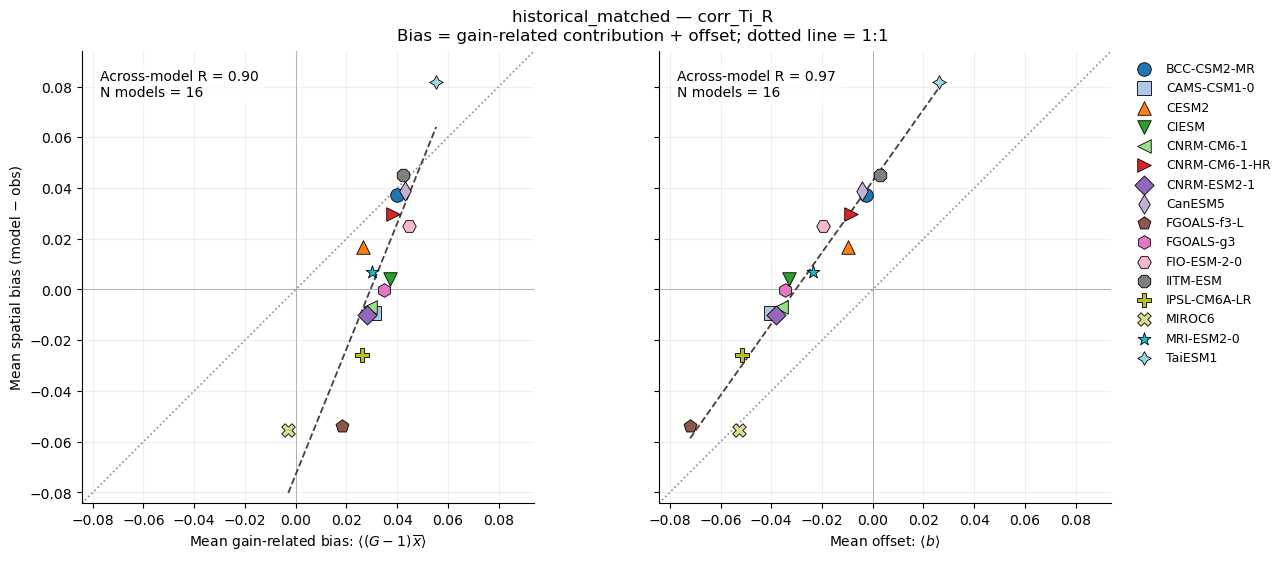

In [35]:
# %% Bias versus its gain-related contribution and its spatially uniform offset.
# Run after the preceding cell: reuse experiment, quantity, bias_key, show_members.
# The member-level identity is B = (G - 1)*mean_x + b = bias_from_gain + offset.
# These are additive bias TERMS, not the gain G and residual amplitude H themselves.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if bias_key not in ["bias", "bias_over_std_x"]:
    raise ValueError("Choose bias or bias_over_std_x so both terms use matching units.")
suffix = "_over_std_x" if bias_key == "bias_over_std_x" else ""
term_keys = ["bias_from_gain", "offset", "bias"]
bias_term_members, term_rows = {}, []
term_model_names = list(overlap_model_names[experiment])

for model in term_model_names:
    d = overlap_member_decomposition[experiment][quantity][model]
    gain_bias, offset, bias = [np.asarray(d[key + suffix], dtype=float) for key in term_keys]
    s, G, H = [np.asarray(d[key], dtype=float) for key in
               ["contrast_ratio", "gain", "residual_std_over_std_x"]]
    if bias.ndim != 1 or any(v.shape != bias.shape for v in [gain_bias, offset, s, G, H]):
        raise ValueError(f"{model}: expected matching one-dimensional member arrays.")

    # Keep the same defined-share members as the previous plot, and require both
    # additive terms to be finite. Use this ONE mask for every mean below.
    # A constant map can have a defined bias budget, but is excluded here solely
    # to keep the member selection comparable to the preceding share panels.
    valid = (np.isfinite(gain_bias) & np.isfinite(offset) & np.isfinite(bias)
             & np.isfinite(s) & np.isfinite(G) & np.isfinite(H) & (s > 0))
    here = {key: values[valid] for key, values in zip(term_keys, [gain_bias, offset, bias])}
    np.testing.assert_allclose(here["bias"], here["bias_from_gain"] + here["offset"],
                               rtol=1e-10, atol=1e-12)
    bias_term_members[model] = here
    term_rows.append({"model": model, "n_members": int(valid.sum()),
                      **{key: values.mean() if values.size else np.nan for key, values in here.items()}})
    if not valid.any():
        print(f"Excluded {model}: no members with all required terms defined.")

# Averaging is linear, so the identity ALSO holds for these matched-member means.
# Retain the table for inspecting magnitudes and cancellation, not just correlations.
bias_term_means = pd.DataFrame(term_rows).set_index("model")
bias_term_means.attrs.update(experiment=experiment, quantity=quantity, bias_key=bias_key)
np.testing.assert_allclose(bias_term_means["bias"],
                           bias_term_means["bias_from_gain"] + bias_term_means["offset"],
                           rtol=1e-10, atol=1e-12, equal_nan=True)

# Identical x/y scales let us compare the sizes of both terms directly.
# Include faint members in the limits when enabled, so none are clipped.
limit_values = bias_term_means[term_keys].to_numpy().ravel()
if show_members:
    limit_values = np.concatenate([limit_values] + [v for d in bias_term_members.values() for v in d.values()])
limit_values = limit_values[np.isfinite(limit_values)]
if limit_values.size:
    lo, hi = min(0., limit_values.min()), max(0., limit_values.max())
    pad = 0.08 * (hi - lo) if hi > lo else 0.1
    term_limits = (lo - pad, hi + pad)
else:
    term_limits = (-1., 1.)

# Reuse the model style assignments from the preceding figure.
shapes = globals().get("TAYLOR_SHAPES", ["o", "s", "D", "^", "v", "<", ">", "p", "h", "P", "X", "*"])
marker_map = globals().get("taylor_markers", {})
term_colors = plt.get_cmap("tab20")(np.linspace(0, 1, max(len(term_model_names), 1)))
term_labels = [r"Mean gain-related bias: $\langle(G-1)\,\overline{x}\rangle$",
               r"Mean offset: $\langle b\rangle$"]
if suffix:
    term_labels = [r"Mean gain-related bias / obs SD: $\langle(G-1)\,\overline{x}/\sigma_x\rangle$",
                   r"Mean offset / obs SD: $\langle b/\sigma_x\rangle$"]

fig_bias_terms, axes_bias_terms = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True, constrained_layout=True)
for ax, key, xlabel in zip(axes_bias_terms, term_keys[:2], term_labels):
    for i, model in enumerate(term_model_names):
        row, here = bias_term_means.loc[model], bias_term_members[model]
        if not np.isfinite(row[key]) or not np.isfinite(row["bias"]):
            continue
        marker = marker_map.get(model, shapes[i % len(shapes)])
        if show_members:
            ax.scatter(here[key], here["bias"], color=term_colors[i], marker=marker,
                       s=25, alpha=0.18, edgecolors="none", zorder=1)
        ax.scatter(row[key], row["bias"], color=term_colors[i], marker=marker, s=95,
                   edgecolors="k", linewidths=0.6, label=model, zorder=3)

    # One equal-weight point per model. The dotted 1:1 line means that the OTHER
    # additive term is zero; the dashed line is the fitted across-model regression.
    x, y = bias_term_means[key].to_numpy(), bias_term_means["bias"].to_numpy()
    valid_models = np.isfinite(x) & np.isfinite(y)
    x, y = x[valid_models], y[valid_models]
    R = np.nan
    if len(x) >= 3 and np.ptp(x) > 0 and np.ptp(y) > 0:
        R = np.corrcoef(x, y)[0, 1]
        slope, intercept = np.polyfit(x, y, 1)
        xx = np.linspace(x.min(), x.max(), 100)
        ax.plot(xx, slope * xx + intercept, "--", color="0.25", linewidth=1.3, zorder=2)
    ax.plot(term_limits, term_limits, ":", color="0.55", linewidth=1.2, zorder=0)
    ax.axhline(0, color="0.65", linewidth=0.6, zorder=0)
    ax.axvline(0, color="0.65", linewidth=0.6, zorder=0)
    ax.text(0.04, 0.96, f"Across-model R = {R:.2f}\nN models = {len(x)}",
            transform=ax.transAxes, ha="left", va="top",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.8))
    ax.set(xlabel=xlabel, xlim=term_limits, ylim=term_limits)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)

ylabel = "Mean spatial bias (model − obs)" if not suffix else "Mean spatial bias / obs spatial SD"
axes_bias_terms[0].set_ylabel(ylabel)
axes_bias_terms[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1), frameon=False, fontsize=9)
fig_bias_terms.suptitle(f"{experiment} — {quantity}\nBias = gain-related contribution + offset; dotted line = 1:1")
# fig_bias_terms.savefig("bias_gain_offset.png", dpi=300, bbox_inches="tight")
plt.show()

# Caution: each x-variable is PART OF the y-variable by construction. A strong
# correlation alone does not establish dominance or causality. Inspect the term
# magnitudes and their cancellation in bias_term_means as well.


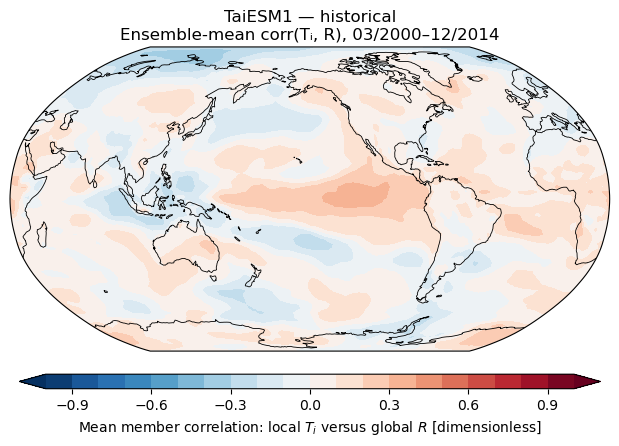

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

# Select the experiment and find TaiESM's position in the saved model-mean array.
experiment, quantity = "historical", "corr_Ti_R"   # Or experiment = "amip_hist".
names = list(overlap_model_names[experiment])
matches = [name for name in names if "taiesm" in str(name).lower()]
if len(matches) != 1:
    raise ValueError(f"Expected one TaiESM model; found {matches}.")
model = matches[0]

# This is the arithmetic mean of the members' temporal-correlation maps,
# NOT the correlation calculated from ensemble-mean temperature/radiation.
map_here = np.asarray(overlap_model_means[experiment][quantity][names.index(model)], dtype=float)
lat, lon = [np.asarray(overlap_coordinates[k]) for k in ["lat", "lon"]]

# Close the longitude seam; use a symmetric color scale centered on zero.
vlim = 1.0                       # Reduce if you want to emphasize smaller values.
if np.isclose(abs(lon[-1] - lon[0]), 360):
    plot_map, plot_lon = map_here, lon
else:
    plot_map, plot_lon = add_cyclic_point(map_here, coord=lon, axis=-1)

fig, ax = plt.subplots(figsize=(10, 5), subplot_kw={"projection": ccrs.Robinson(central_longitude=210)})
im = ax.contourf(plot_lon, lat, np.ma.masked_invalid(plot_map),
                levels=np.linspace(-vlim, vlim, 21), cmap="RdBu_r",
                extend="both", transform=ccrs.PlateCarree())
ax.set_global()
ax.coastlines(linewidth=.6)
ax.set_title(f"{model} — {experiment}\nEnsemble-mean corr(Tᵢ, R), 03/2000–12/2014")

cb = fig.colorbar(im, ax=ax, orientation="horizontal", pad=.06, shrink=.75, aspect=40)
cb.set_label(r"Mean member correlation: local $T_i$ versus global $R$ [dimensionless]")
plt.show()

In [26]:
overlap_member_ids

{'amip_hist': {'BCC-CSM2-MR': array(['r1i1p1f1'], dtype='<U8'),
  'CAMS-CSM1-0': array(['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1'], dtype='<U8'),
  'CESM2': array(['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1'], dtype='<U8'),
  'CIESM': array(['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1'], dtype='<U8'),
  'CNRM-CM6-1': array(['r1i1p1f2', 'r2i1p1f2', 'r3i1p1f2', 'r4i1p1f2', 'r5i1p1f2',
         'r6i1p1f2', 'r7i1p1f2', 'r8i1p1f2', 'r9i1p1f2', 'r10i1p1f2'],
        dtype='<U9'),
  'CNRM-CM6-1-HR': array(['r1i1p1f2'], dtype='<U8'),
  'CNRM-ESM2-1': array(['r1i1p1f2'], dtype='<U8'),
  'CanESM5': array(['r1i1p2f1', 'r2i1p2f1', 'r3i1p2f1', 'r4i1p2f1', 'r5i1p2f1',
         'r6i1p2f1', 'r7i1p2f1', 'r8i1p2f1', 'r9i1p2f1', 'r10i1p2f1'],
        dtype='<U9'),
  'FGOALS-f3-L': array(['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1'], dtype='<U8'),
  'FGOALS-g3': array(['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1', 'r4i1p1f1'], dtype='<U8'),
  'FIO-ESM-2-0': array(['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1'], dtype='<U8'),
  'IITM-ESM': array(['r1i1p1f1'], d

In [25]:
overlap_model_means['historical_matched']['corr_Ti_R']

array([[[-0.16500081, -0.16546122, -0.16655155, ..., -0.1628485 ,
         -0.16324897, -0.16412721],
        [-0.16704827, -0.16805195, -0.16937975, ..., -0.1648436 ,
         -0.16551473, -0.16625786],
        [-0.15921491, -0.15964079, -0.1604755 , ..., -0.16013002,
         -0.1597047 , -0.15951061],
        ...,
        [-0.04415607, -0.03975619, -0.03631013, ..., -0.06335653,
         -0.05547791, -0.04867252],
        [-0.05644967, -0.05572133, -0.05525935, ..., -0.05862299,
         -0.05778427, -0.05694053],
        [-0.07173492, -0.0723813 , -0.07252263, ..., -0.06993334,
         -0.07049419, -0.07108399]],

       [[ 0.00756975,  0.00849665,  0.0107935 , ...,  0.00861172,
          0.00742543,  0.00792885],
        [-0.01101813, -0.01023741, -0.01100328, ..., -0.00856538,
         -0.00993757, -0.010692  ],
        [-0.01857471, -0.0192038 , -0.02066605, ..., -0.01192031,
         -0.01517804, -0.01681611],
        ...,
        [ 0.07518724,  0.07924208,  0.0832484 , ...,  

In [ ]:
plot_map()

In [10]:
overlap_mean_member_decomposition['historical_matched']['corr_Ti_R']

{'BCC-CSM2-MR': {'gain': 0.2761814713662179,
  'offset': -0.002666616675094696,
  'pattern_std': 0.035348675803884115,
  'residual_std': 0.13324476175823716,
  'pattern_std_over_std_x': 0.2761814713662179,
  'residual_std_over_std_y': 0.9647922664888515,
  'pattern_variance_fraction': 0.06904737436619822,
  'residual_variance_fraction': 0.9309526256338018,
  'bias_from_gain': 0.03987854916025529,
  'bias': 0.03721193248516059,
  'pattern_correlation': 0.2591759581974838,
  'contrast_ratio': 1.0781537307943418,
  'offset_over_std_x': -0.020834447122809092,
  'residual_std_over_std_x': 1.0410498701110478,
  'bias_from_gain_over_std_x': 0.31157366245156964,
  'bias_over_std_x': 0.2907392153287605},
 'CAMS-CSM1-0': {'gain': 0.4384787019496567,
  'offset': -0.04007991596834536,
  'pattern_std': 0.05612122133122301,
  'residual_std': 0.13471423861595105,
  'pattern_std_over_std_x': 0.4384787019496567,
  'residual_std_over_std_y': 0.9227009076733529,
  'pattern_variance_fraction': 0.148474141